<a href="https://colab.research.google.com/github/RB1Student/ISYS2001-Assignment-2-Project/blob/main/pt3_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import matplotlib

In [47]:
!pip install google-genai

In [48]:
from google.colab import userdata
from google import genai

# The client reads your key from Secrets, so the key itself never appears here.
client = genai.Client(api_key=userdata.get("GOOGLE_API_KEY"))

# The flash model is fast and free-tier friendly. The exact name changes every
# few months, so check AI Studio for the current one and edit this single line.
MODEL = "gemini-3.5-flash"

print("Connected to the Gemini API.")

Connected to the Gemini API.


In [50]:
#Grab the name of the user

User = input("What is your name? ")

What is your name? Ross


In [51]:
#Import bank statement

print("-- Could youn please upload your bank statement hear in CSV Format--")

from google.colab import files
uploaded = files.upload()


-- Could youn please upload your bank statement hear in CSV Format--


Saving Sample Bank Statement.csv to Sample Bank Statement (2).csv


In [52]:
Bank_Statement = pd.read_csv("/content/Sample Bank Statement.csv")

In [53]:
print(Bank_Statement)

          Date               Name     Type      Income     Expense  \
0     1/9/2026    Opening Balance  Balance           —           —   
1     5/9/2026             Salary   Income  $3,000.00            —   
2    12/9/2026        Supermarket  Expense           —    $125.40    
3    18/9/2026       Fuel Station  Expense           —     $85.00    
4    25/9/2026               Rent  Expense           —  $1,500.00    
5    30/9/2026  Transfer Received   Income    $500.00            —   
6    3/10/2026             Salary   Income  $3,000.00            —   
7    8/10/2026   Electricity Bill  Expense           —    $145.00    
8   14/10/2026      Grocery Store  Expense           —     $98.75    
9   20/10/2026         Restaurant  Expense           —     $72.50    
10  27/10/2026  Freelance Payment   Income    $750.00            —   
11  31/10/2026      Internet Bill  Expense           —     $79.00    
12   3/11/2026             Salary   Income  $3,000.00            —   
13   8/11/2026      

In [55]:
def clean_money(series):
    return (
        series.astype(str)
        .str.replace(r"[^\d.\-]", "", regex=True)  # remove $, commas, spaces, and the "—" dash
        .replace("", "0")                          # empty strings (from "—") become 0
        .astype(float)
    )

for col in ["Income", "Expense", "Balance"]:
    Bank_Statement[col] = clean_money(Bank_Statement[col])

In [57]:
#Filter Input for date and Category

import ipywidgets as widgets
from IPython.display import display, HTML # Added HTML import

# 1. Make Date a real date (your dates are day/month/year)
Bank_Statement["Date"] = pd.to_datetime(Bank_Statement["Date"], dayfirst=True)
Bank_Statement["Month"] = Bank_Statement["Date"].dt.strftime("%B %Y")   # e.g. "October 2026"

# 2. Build the dropdowns
month_options = ["All"] + list(Bank_Statement["Month"].unique())
category_options = ["All"] + sorted(Bank_Statement["Name"].unique())

month_dd = widgets.Dropdown(options=month_options, description="Month:")
category_dd = widgets.Dropdown(options=category_options, description="Category:")

output = widgets.Output()

# 3. Filter + recalculate whenever a dropdown changes
def update(change=None):
    global Filtered_Statement
    Filtered_Statement = Bank_Statement.copy()

    if month_dd.value != "All":
        Filtered_Statement = Filtered_Statement[Filtered_Statement["Month"] == month_dd.value]
    if category_dd.value != "All":
        Filtered_Statement = Filtered_Statement[Filtered_Statement["Name"] == category_dd.value]

    with output:
        output.clear_output()
        if Filtered_Statement.empty:
            display(HTML("<div style='background-color: #fff3e0; padding: 10px; border-left: 5px solid #ff9800; border-radius: 5px; color: #e65100;'>No transactions match those filters. Please adjust your selections.</div>"))
            return

month_dd.observe(update, names="value")
category_dd.observe(update, names="value")

display(month_dd, category_dd, output)
update()   # show results on first load


Dropdown(description='Month:', options=('All', 'September 2026', 'October 2026', 'November 2026'), value='All'…

Dropdown(description='Category:', options=('All', 'Clothing Store', 'Coffee Shop', 'Electricity Bill', 'Freela…

Output()

In [58]:
#Current Balance

# Opening balance (run this once, outside update())
Opening_Balance = Bank_Statement.loc[Bank_Statement["Type"] == "Balance", "Balance"].iloc[0]

# Inside update(), after Filtered_Statement is built:
Total_Income = Filtered_Statement["Income"].sum()
Total_Expense = Filtered_Statement["Expense"].sum()

Current_Balance = Opening_Balance + Total_Income - Total_Expense
print(f"${Current_Balance:,.2f}")

$11,635.25


In [59]:
#Total Income Earned

Total_Income = Filtered_Statement['Income'].sum()

print(f'${Total_Income:.2f}')

$10650.00


In [60]:
#Total Expense Earned

Total_Expense = Filtered_Statement['Expense'].sum()

print(f'${Total_Expense:.2f}')

$4014.75


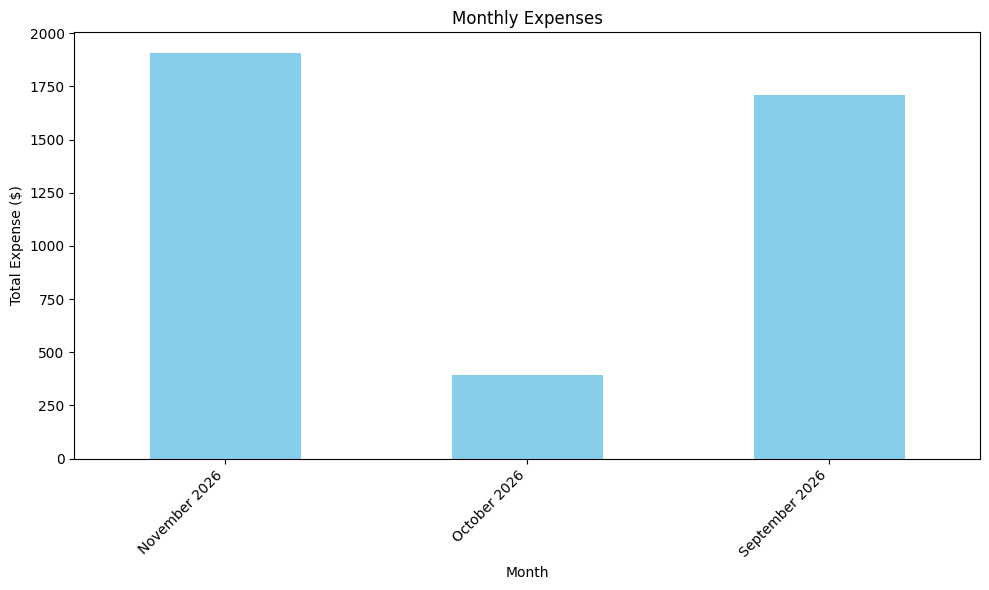

In [61]:
# Bar Char of Monthly Expense
import matplotlib.pyplot as plt

if not Filtered_Statement.empty:
    monthly_expense = Filtered_Statement.groupby('Month')['Expense'].sum()

    plt.figure(figsize=(10, 6))
    monthly_expense.plot(kind='bar', color='skyblue')
    plt.title('Monthly Expenses')
    plt.xlabel('Month')
    plt.ylabel('Total Expense ($)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot monthly expenses based on current filters.")

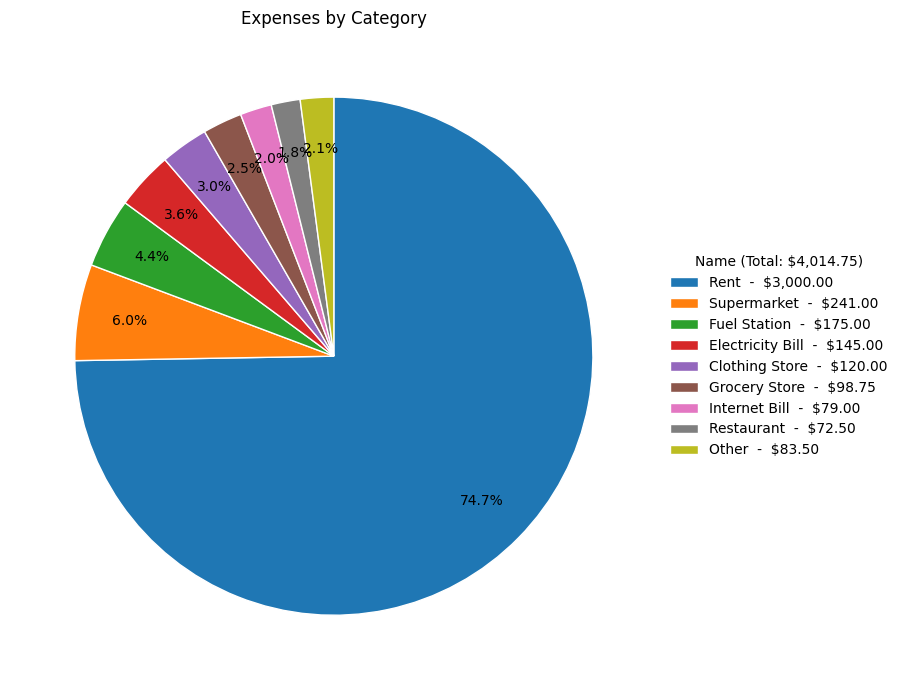

In [63]:
# Pie Chart of Expenses by Category (with legend showing amounts)
import matplotlib.pyplot as plt

def plot_expense_pie(df, category_col='Name', top_n=8):
    if df.empty:
        print("No data available to plot expense categories based on current filters.")
        return

    category_expense = (
        df.groupby(category_col)['Expense'].sum()
        .loc[lambda s: s > 0]                 # pie charts can't show zero/negative values
        .sort_values(ascending=False)
    )

    if category_expense.empty:
        print("No positive expenses to plot for the current filters.")
        return

    # Group small categories into "Other" so the chart stays readable
    if len(category_expense) > top_n:
        top = category_expense.iloc[:top_n]
        other = category_expense.iloc[top_n:].sum()
        category_expense = top.copy()
        category_expense['Other'] = other

    total = category_expense.sum()

    fig, ax = plt.subplots(figsize=(11, 7))
    wedges, texts, autotexts = ax.pie(
        category_expense,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
        pctdistance=0.8,
        wedgeprops={'edgecolor': 'white'}
    )

    # Key: name + expense amount
    legend_labels = [f"{name}  -  ${amount:,.2f}" for name, amount in category_expense.items()]
    ax.legend(
        wedges,
        legend_labels,
        title=f"{category_col} (Total: ${total:,.2f})",
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        frameon=False
    )

    ax.set_title('Expenses by Category')
    plt.tight_layout()
    plt.show()

plot_expense_pie(Filtered_Statement)

In [64]:
import ipywidgets as widgets
from IPython.display import display
from google.genai import types

# Start a chat that already knows the bank statement
chat = client.chats.create(
    model=MODEL,
    config=types.GenerateContentConfig(
        system_instruction=(
            f"You are a friendly finance assistant talking to {User}. "
            "Answer using only this bank statement:\n\n"
            + Bank_Statement.to_csv(index=False)
        )
    ),
)

# The chat window parts
chat_area = widgets.Output()
text_box = widgets.Text(placeholder="Ask about your spending...")
send_btn = widgets.Button(description="Send")


def send(_):
    question = text_box.value
    if not question:
        return
    text_box.value = ""
    with chat_area:
        print(f"You: {question}")
        reply = chat.send_message(question).text
        print(f"Gemini: {reply}\n")


send_btn.on_click(send)
text_box.on_submit(send)  # press Enter to send

display(chat_area, widgets.HBox([text_box, send_btn]))

Output()

** Making it into a dashboard**

In [68]:
# =====================================================
#  BANK STATEMENT DASHBOARD  (Google Colab)
#  Paste this whole thing into ONE Colab cell and run it.
# =====================================================
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML
from google.colab import files

# ---------- 1. User + upload ----------
User = input("What is your name? ")

print("-- Please upload your bank statement in CSV format --")
uploaded = files.upload()
filename = next(iter(uploaded))          # use whatever file name was uploaded
Bank_Statement = pd.read_csv(filename)


# ---------- 2. Clean the data ----------
def clean_money(series):
    return (
        series.astype(str)
        .str.replace(r"[^\d.\-]", "", regex=True)   # remove $, commas, spaces, "—"
        .replace("", "0")                           # empty strings become 0
        .astype(float)
    )


for col in ["Income", "Expense", "Balance"]:
    Bank_Statement[col] = clean_money(Bank_Statement[col])

Bank_Statement["Date"] = pd.to_datetime(Bank_Statement["Date"], dayfirst=True)
Bank_Statement["Month"] = Bank_Statement["Date"].dt.strftime("%B %Y")   # e.g. "October 2026"


# ---------- 3. Dashboard pieces ----------
def kpi_card(title, value, colour="#1a237e"):
    return f"""
    <div style="flex:1; min-width:180px; background:#ffffff; border-radius:10px;
                padding:16px 20px; box-shadow:0 2px 6px rgba(0,0,0,0.15);
                border-top:5px solid {colour}; font-family:Arial, sans-serif;">
        <div style="font-size:13px; color:#666; text-transform:uppercase;">{title}</div>
        <div style="font-size:26px; font-weight:bold; color:{colour}; margin-top:6px;">{value}</div>
    </div>"""


def plot_charts(df, top_n=8):
    """Bar chart (monthly expense) and pie chart (expense by category) side by side."""
    fig, (ax_bar, ax_pie) = plt.subplots(
        1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.1]}
    )

    # --- Bar chart: monthly expense ---
    monthly_expense = df.groupby("Month", sort=False)["Expense"].sum()
    monthly_expense.plot(kind="bar", color="skyblue", ax=ax_bar)
    ax_bar.set_title("Monthly Expenses")
    ax_bar.set_xlabel("Month")
    ax_bar.set_ylabel("Total Expense ($)")
    ax_bar.tick_params(axis="x", rotation=45)

    # --- Pie chart: expense by category ---
    category_expense = (
        df.groupby("Name")["Expense"].sum()
        .loc[lambda s: s > 0]
        .sort_values(ascending=False)
    )

    if category_expense.empty:
        ax_pie.text(0.5, 0.5, "No expenses to show", ha="center", va="center")
        ax_pie.axis("off")
    else:
        if len(category_expense) > top_n:
            top = category_expense.iloc[:top_n]
            other = category_expense.iloc[top_n:].sum()
            category_expense = top.copy()
            category_expense["Other"] = other

        total = category_expense.sum()
        wedges, texts, autotexts = ax_pie.pie(
            category_expense,
            autopct="%1.1f%%",
            startangle=90,
            counterclock=False,
            pctdistance=0.8,
            wedgeprops={"edgecolor": "white"},
        )
        labels = [f"{name}  -  ${amt:,.2f}" for name, amt in category_expense.items()]
        ax_pie.legend(
            wedges,
            labels,
            title=f"Category (Total: ${total:,.2f})",
            loc="upper center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=2,
            frameon=False,
        )
        ax_pie.set_title("Expenses by Category")

    plt.tight_layout()
    plt.show()


def display_financial_dashboard(df):
    """Joins the KPI cards, charts and transaction table into one dashboard."""
    balance = df["Balance"].iloc[-1]
    income = df["Income"].sum()
    expense = df["Expense"].sum()
    net = income - expense
    net_colour = "#2e7d32" if net >= 0 else "#c62828"

    # Header + KPI cards
    display(HTML(f"""
    <div style="font-family:Arial, sans-serif; margin:10px 0 15px 0;">
        <h2 style="margin:0; color:#1a237e;">{User}'s Financial Dashboard</h2>
        <div style="color:#666; font-size:13px;">Showing {len(df)} transaction(s)</div>
    </div>
    <div style="display:flex; gap:15px; flex-wrap:wrap; margin-bottom:20px;">
        {kpi_card("Current Balance", f"${balance:,.2f}", "#1a237e")}
        {kpi_card("Total Income", f"${income:,.2f}", "#2e7d32")}
        {kpi_card("Total Expense", f"${expense:,.2f}", "#c62828")}
        {kpi_card("Net (Income - Expense)", f"${net:,.2f}", net_colour)}
    </div>
    """))

    # Charts
    plot_charts(df)

    # Transactions table
    display(HTML("<h3 style='font-family:Arial, sans-serif; color:#1a237e;'>Transactions</h3>"))
    display(df.drop(columns="Month").reset_index(drop=True))


# ---------- 4. Filters (dropdowns) ----------
month_options = ["All"] + list(Bank_Statement["Month"].unique())
category_options = ["All"] + sorted(Bank_Statement["Name"].unique())

month_dd = widgets.Dropdown(options=month_options, description="Month:")
category_dd = widgets.Dropdown(options=category_options, description="Category:")
output = widgets.Output()


def update(change=None):
    global Filtered_Statement
    Filtered_Statement = Bank_Statement.copy()

    if month_dd.value != "All":
        Filtered_Statement = Filtered_Statement[Filtered_Statement["Month"] == month_dd.value]
    if category_dd.value != "All":
        Filtered_Statement = Filtered_Statement[Filtered_Statement["Name"] == category_dd.value]

    with output:
        output.clear_output(wait=True)
        if Filtered_Statement.empty:
            display(HTML(
                "<div style='background-color:#fff3e0; padding:10px; border-left:5px solid #ff9800;"
                "border-radius:5px; color:#e65100;'>No transactions match those filters. "
                "Please adjust your selections.</div>"
            ))
            return
        display_financial_dashboard(Filtered_Statement)


month_dd.observe(update, names="value")
category_dd.observe(update, names="value")

display(widgets.HBox([month_dd, category_dd]), output)
update()   # show the dashboard on first load

What is your name? Ross
-- Please upload your bank statement in CSV format --


Saving Sample Bank Statement 6 Months.csv to Sample Bank Statement 6 Months.csv


Output()

** app Part 2 **

In [65]:
# =====================================================
#  BANK STATEMENT DASHBOARD + CHATBOT  (Google Colab)
#  Paste this whole thing into ONE Colab cell and run it.
# =====================================================
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML
from google.colab import files, userdata
from google import genai
from google.genai import types

# ---------- 0. Connect to Gemini ----------
client = genai.Client(api_key=userdata.get("GOOGLE_API_KEY"))
MODEL = "gemini-3.5-flash"   # check AI Studio for the current model name


# ---------- 1. User + upload ----------
User = input("What is your name? ")

print("-- Please upload your bank statement in CSV format --")
uploaded = files.upload()
filename = next(iter(uploaded))          # use whatever file name was uploaded
Bank_Statement = pd.read_csv(filename)


# ---------- 2. Clean the data ----------
def clean_money(series):
    return (
        series.astype(str)
        .str.replace(r"[^\d.\-]", "", regex=True)   # remove $, commas, spaces, "—"
        .replace("", "0")                           # empty strings become 0
        .astype(float)
    )


for col in ["Income", "Expense", "Balance"]:
    Bank_Statement[col] = clean_money(Bank_Statement[col])

Bank_Statement["Date"] = pd.to_datetime(Bank_Statement["Date"], dayfirst=True)
Bank_Statement["Month"] = Bank_Statement["Date"].dt.strftime("%B %Y")   # e.g. "October 2026"


# ---------- 3. Dashboard pieces ----------
def kpi_card(title, value, colour="#1a237e"):
    return f"""
    <div style="flex:1; min-width:180px; background:#ffffff; border-radius:10px;
                padding:16px 20px; box-shadow:0 2px 6px rgba(0,0,0,0.15);
                border-top:5px solid {colour}; font-family:Arial, sans-serif;">
        <div style="font-size:13px; color:#666; text-transform:uppercase;">{title}</div>
        <div style="font-size:26px; font-weight:bold; color:{colour}; margin-top:6px;">{value}</div>
    </div>"""


def plot_charts(df, top_n=8):
    """Bar chart (monthly expense) and pie chart (expense by category) side by side."""
    fig, (ax_bar, ax_pie) = plt.subplots(
        1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.1]}
    )

    # --- Bar chart: monthly expense ---
    monthly_expense = df.groupby("Month", sort=False)["Expense"].sum()
    monthly_expense.plot(kind="bar", color="skyblue", ax=ax_bar)
    ax_bar.set_title("Monthly Expenses")
    ax_bar.set_xlabel("Month")
    ax_bar.set_ylabel("Total Expense ($)")
    ax_bar.tick_params(axis="x", rotation=45)

    # --- Pie chart: expense by category ---
    category_expense = (
        df.groupby("Name")["Expense"].sum()
        .loc[lambda s: s > 0]
        .sort_values(ascending=False)
    )

    if category_expense.empty:
        ax_pie.text(0.5, 0.5, "No expenses to show", ha="center", va="center")
        ax_pie.axis("off")
    else:
        if len(category_expense) > top_n:
            top = category_expense.iloc[:top_n]
            other = category_expense.iloc[top_n:].sum()
            category_expense = top.copy()
            category_expense["Other"] = other

        total = category_expense.sum()
        wedges, texts, autotexts = ax_pie.pie(
            category_expense,
            autopct="%1.1f%%",
            startangle=90,
            counterclock=False,
            pctdistance=0.8,
            wedgeprops={"edgecolor": "white"},
        )
        labels = [f"{name}  -  ${amt:,.2f}" for name, amt in category_expense.items()]
        ax_pie.legend(
            wedges,
            labels,
            title=f"Category (Total: ${total:,.2f})",
            loc="upper center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=2,
            frameon=False,
        )
        ax_pie.set_title("Expenses by Category")

    plt.tight_layout()
    plt.show()


def display_financial_dashboard(df):
    """Joins the KPI cards, charts and transaction table into one dashboard."""
    balance = df["Balance"].iloc[-1]
    income = df["Income"].sum()
    expense = df["Expense"].sum()
    net = income - expense
    net_colour = "#2e7d32" if net >= 0 else "#c62828"

    # Header + KPI cards
    display(HTML(f"""
    <div style="font-family:Arial, sans-serif; margin:10px 0 15px 0;">
        <h2 style="margin:0; color:#1a237e;">{User}'s Financial Dashboard</h2>
        <div style="color:#666; font-size:13px;">Showing {len(df)} transaction(s)</div>
    </div>
    <div style="display:flex; gap:15px; flex-wrap:wrap; margin-bottom:20px;">
        {kpi_card("Current Balance", f"${balance:,.2f}", "#1a237e")}
        {kpi_card("Total Income", f"${income:,.2f}", "#2e7d32")}
        {kpi_card("Total Expense", f"${expense:,.2f}", "#c62828")}
        {kpi_card("Net (Income - Expense)", f"${net:,.2f}", net_colour)}
    </div>
    """))

    # Charts
    plot_charts(df)

    # Transactions table
    display(HTML("<h3 style='font-family:Arial, sans-serif; color:#1a237e;'>Transactions</h3>"))
    display(df.drop(columns="Month").reset_index(drop=True))


# ---------- 4. Filters (dropdowns) ----------
month_options = ["All"] + list(Bank_Statement["Month"].unique())
category_options = ["All"] + sorted(Bank_Statement["Name"].unique())

month_dd = widgets.Dropdown(options=month_options, description="Month:")
category_dd = widgets.Dropdown(options=category_options, description="Category:")
output = widgets.Output()


def update(change=None):
    global Filtered_Statement
    Filtered_Statement = Bank_Statement.copy()

    if month_dd.value != "All":
        Filtered_Statement = Filtered_Statement[Filtered_Statement["Month"] == month_dd.value]
    if category_dd.value != "All":
        Filtered_Statement = Filtered_Statement[Filtered_Statement["Name"] == category_dd.value]

    with output:
        output.clear_output(wait=True)
        if Filtered_Statement.empty:
            display(HTML(
                "<div style='background-color:#fff3e0; padding:10px; border-left:5px solid #ff9800;"
                "border-radius:5px; color:#e65100;'>No transactions match those filters. "
                "Please adjust your selections.</div>"
            ))
            return
        display_financial_dashboard(Filtered_Statement)


month_dd.observe(update, names="value")
category_dd.observe(update, names="value")

dashboard_screen = widgets.VBox([widgets.HBox([month_dd, category_dd]), output])


# ---------- 5. Chatbot ----------
chat = client.chats.create(
    model=MODEL,
    config=types.GenerateContentConfig(
        system_instruction=(
            f"You are a friendly finance assistant talking to {User}. "
            "Answer using only this bank statement:\n\n"
            + Bank_Statement.drop(columns="Month").to_csv(index=False)
        )
    ),
)

chat_area = widgets.Output()
text_box = widgets.Text(
    placeholder="Ask about your spending...",
    layout=widgets.Layout(width="500px"),
)
send_btn = widgets.Button(description="Send", button_style="primary")


def send(_):
    question = text_box.value
    if not question:
        return
    text_box.value = ""
    with chat_area:
        print(f"You: {question}")
        try:
            reply = chat.send_message(question).text
        except Exception as error:
            reply = f"Something went wrong talking to the API: {error}"
        print(f"Gemini: {reply}\n")


send_btn.on_click(send)
text_box.on_submit(send)  # press Enter to send

chat_screen = widgets.VBox([
    widgets.HTML(f"<h2 style='font-family:Arial, sans-serif; color:#1a237e;'>"
                 f"Hi {User}! Ask me about your bank statement</h2>"),
    chat_area,
    widgets.HBox([text_box, send_btn]),
])


# ---------- 6. Tabs to switch screens ----------
tabs = widgets.Tab(children=[dashboard_screen, chat_screen])
tabs.set_title(0, "📊 Dashboard")
tabs.set_title(1, "💬 Chatbot")

display(tabs)
update()   # show the dashboard on first load

What is your name? Ross
-- Please upload your bank statement in CSV format --


Saving Sample Bank Statement.csv to Sample Bank Statement (3).csv


** Part 3**

In [69]:
# =====================================================
#  BANK STATEMENT APP: ACCOUNT + DASHBOARD + CHATBOT
#  Paste this whole thing into ONE Colab cell and run it.
# =====================================================
import io
import html
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML
from google.colab import userdata
from google import genai
from google.genai import types

# ---------- 0. Connect to Gemini ----------
client = genai.Client(api_key=userdata.get("GOOGLE_API_KEY"))
MODEL = "gemini-3.5-flash"   # check AI Studio for the current model name


# ---------- 1. Loading + cleaning the CSV ----------
def read_uploaded_csv(upload_widget):
    """Read the file from the upload button (works with old and new ipywidgets)."""
    value = upload_widget.value
    if isinstance(value, dict):          # older ipywidgets
        filename = next(iter(value.keys()))
        file_info = value[filename]
    else:                                # newer ipywidgets
        file_info = value[0]
        filename = file_info["name"]
    df = pd.read_csv(io.BytesIO(bytes(file_info["content"])))
    return df, filename


def clean_money(series):
    return (
        series.astype(str)
        .str.replace(r"[^\d.\-]", "", regex=True)   # remove $, commas, spaces, "—"
        .replace("", "0")                           # empty strings become 0
        .astype(float)
    )


def clean_statement(df):
    for col in ["Income", "Expense", "Balance"]:
        df[col] = clean_money(df[col])
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df["Month"] = df["Date"].dt.strftime("%B %Y")   # e.g. "October 2026"
    return df


# ---------- 2. Dashboard pieces ----------
def kpi_card(title, value, colour="#1a237e"):
    return f"""
    <div style="flex:1; min-width:180px; background:#ffffff; border-radius:10px;
                padding:16px 20px; box-shadow:0 2px 6px rgba(0,0,0,0.15);
                border-top:5px solid {colour}; font-family:Arial, sans-serif;">
        <div style="font-size:13px; color:#666; text-transform:uppercase;">{title}</div>
        <div style="font-size:26px; font-weight:bold; color:{colour}; margin-top:6px;">{value}</div>
    </div>"""


def plot_charts(df, top_n=8):
    """Bar chart (monthly expense) and pie chart (expense by category) side by side."""
    fig, (ax_bar, ax_pie) = plt.subplots(
        1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.1]}
    )

    # --- Bar chart: monthly expense ---
    monthly_expense = df.groupby("Month", sort=False)["Expense"].sum()
    monthly_expense.plot(kind="bar", color="skyblue", ax=ax_bar)
    ax_bar.set_title("Monthly Expenses")
    ax_bar.set_xlabel("Month")
    ax_bar.set_ylabel("Total Expense ($)")
    ax_bar.tick_params(axis="x", rotation=45)

    # --- Pie chart: expense by category ---
    category_expense = (
        df.groupby("Name")["Expense"].sum()
        .loc[lambda s: s > 0]
        .sort_values(ascending=False)
    )

    if category_expense.empty:
        ax_pie.text(0.5, 0.5, "No expenses to show", ha="center", va="center")
        ax_pie.axis("off")
    else:
        if len(category_expense) > top_n:
            top = category_expense.iloc[:top_n]
            other = category_expense.iloc[top_n:].sum()
            category_expense = top.copy()
            category_expense["Other"] = other

        total = category_expense.sum()
        wedges, texts, autotexts = ax_pie.pie(
            category_expense,
            autopct="%1.1f%%",
            startangle=90,
            counterclock=False,
            pctdistance=0.8,
            wedgeprops={"edgecolor": "white"},
        )
        labels = [f"{name}  -  ${amt:,.2f}" for name, amt in category_expense.items()]
        ax_pie.legend(
            wedges,
            labels,
            title=f"Category (Total: ${total:,.2f})",
            loc="upper center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=2,
            frameon=False,
        )
        ax_pie.set_title("Expenses by Category")

    plt.tight_layout()
    plt.show()


def display_financial_dashboard(df, user):
    """Joins the KPI cards, charts and transaction table into one dashboard."""
    balance = df["Balance"].iloc[-1]
    income = df["Income"].sum()
    expense = df["Expense"].sum()
    net = income - expense
    net_colour = "#2e7d32" if net >= 0 else "#c62828"

    display(HTML(f"""
    <div style="font-family:Arial, sans-serif; margin:10px 0 15px 0;">
        <h2 style="margin:0; color:#1a237e;">{html.escape(user)}'s Financial Dashboard</h2>
        <div style="color:#666; font-size:13px;">Showing {len(df)} transaction(s)</div>
    </div>
    <div style="display:flex; gap:15px; flex-wrap:wrap; margin-bottom:20px;">
        {kpi_card("Current Balance", f"${balance:,.2f}", "#1a237e")}
        {kpi_card("Total Income", f"${income:,.2f}", "#2e7d32")}
        {kpi_card("Total Expense", f"${expense:,.2f}", "#c62828")}
        {kpi_card("Net (Income - Expense)", f"${net:,.2f}", net_colour)}
    </div>
    """))

    plot_charts(df)

    display(HTML("<h3 style='font-family:Arial, sans-serif; color:#1a237e;'>Transactions</h3>"))
    display(df.drop(columns="Month").reset_index(drop=True))


def build_dashboard_screen(df, user):
    """Dropdown filters + dashboard output."""
    month_dd = widgets.Dropdown(
        options=["All"] + list(df["Month"].unique()), description="Month:"
    )
    category_dd = widgets.Dropdown(
        options=["All"] + sorted(df["Name"].unique()), description="Category:"
    )
    output = widgets.Output()

    def update(change=None):
        filtered = df.copy()
        if month_dd.value != "All":
            filtered = filtered[filtered["Month"] == month_dd.value]
        if category_dd.value != "All":
            filtered = filtered[filtered["Name"] == category_dd.value]

        with output:
            output.clear_output(wait=True)
            if filtered.empty:
                display(HTML(
                    "<div style='background-color:#fff3e0; padding:10px; border-left:5px solid #ff9800;"
                    "border-radius:5px; color:#e65100;'>No transactions match those filters. "
                    "Please adjust your selections.</div>"
                ))
                return
            display_financial_dashboard(filtered, user)

    month_dd.observe(update, names="value")
    category_dd.observe(update, names="value")
    update()   # show the dashboard straight away

    return widgets.VBox([widgets.HBox([month_dd, category_dd]), output])


# ---------- 3. Chatbot screen ----------
def build_chat_screen(df, user):
    chat = client.chats.create(
        model=MODEL,
        config=types.GenerateContentConfig(
            system_instruction=(
                f"You are a friendly finance assistant talking to {user}. "
                "Answer using only this bank statement:\n\n"
                + df.drop(columns="Month").to_csv(index=False)
            )
        ),
    )

    chat_area = widgets.Output()
    text_box = widgets.Text(
        placeholder="Ask about your spending...",
        layout=widgets.Layout(width="500px"),
    )
    send_btn = widgets.Button(description="Send", button_style="primary")

    def send(_):
        question = text_box.value
        if not question:
            return
        text_box.value = ""
        with chat_area:
            print(f"You: {question}")
            try:
                reply = chat.send_message(question).text
            except Exception as error:
                reply = f"Something went wrong talking to the API: {error}"
            print(f"Gemini: {reply}\n")

    send_btn.on_click(send)
    text_box.on_submit(send)  # press Enter to send

    return widgets.VBox([
        widgets.HTML(f"<h2 style='font-family:Arial, sans-serif; color:#1a237e;'>"
                     f"Hi {html.escape(user)}! Ask me about your bank statement</h2>"),
        chat_area,
        widgets.HBox([text_box, send_btn]),
    ])


# ---------- 4. Account screen (log in / log off) ----------
def message_box(text, colour="#e65100", background="#fff3e0"):
    return (f"<div style='background:{background}; padding:10px; border-left:5px solid {colour};"
            f"border-radius:5px; color:{colour}; font-family:Arial, sans-serif;'>{text}</div>")


def placeholder(text):
    return widgets.HTML(message_box(text, colour="#1a237e", background="#e8eaf6"))


account_box = widgets.VBox()
dashboard_box = widgets.VBox()
chat_box = widgets.VBox()


def show_login_screen():
    name_box = widgets.Text(placeholder="Your name", description="Name:")
    upload = widgets.FileUpload(accept=".csv", multiple=False, description="Upload CSV")
    start_btn = widgets.Button(description="Load my statement", button_style="success", icon="check")
    message = widgets.HTML()

    def start(_):
        name = name_box.value.strip()
        if not name:
            message.value = message_box("Please enter your name.")
            return
        if not upload.value:
            message.value = message_box("Please upload your bank statement CSV.")
            return
        try:
            df, filename = read_uploaded_csv(upload)
            df = clean_statement(df)
        except Exception as error:
            message.value = message_box(f"Couldn't read that file: {html.escape(str(error))}")
            return
        log_in(name, df, filename)

    start_btn.on_click(start)

    account_box.children = [
        widgets.HTML("<h2 style='font-family:Arial, sans-serif; color:#1a237e;'>Welcome! Let's get started</h2>"),
        name_box,
        upload,
        start_btn,
        message,
    ]
    waiting = "Please enter your name and upload your CSV on the 👤 Account tab first."
    dashboard_box.children = [placeholder(waiting)]
    chat_box.children = [placeholder(waiting)]


def log_in(name, df, filename):
    global User, Bank_Statement
    User = name
    Bank_Statement = df

    logoff_btn = widgets.Button(description="Log off", button_style="danger", icon="sign-out")
    logoff_btn.on_click(log_off)

    account_box.children = [
        widgets.HTML(message_box(
            f"Logged in as <b>{html.escape(name)}</b><br>"
            f"File: {html.escape(filename)} ({len(df)} transactions)",
            colour="#2e7d32", background="#e8f5e9",
        )),
        logoff_btn,
    ]
    dashboard_box.children = [build_dashboard_screen(df, name)]
    chat_box.children = [build_chat_screen(df, name)]
    tabs.selected_index = 1   # jump to the dashboard


def log_off(_):
    global User, Bank_Statement
    User = None
    Bank_Statement = None
    show_login_screen()       # wipes the dashboard, chat and upload
    tabs.selected_index = 0   # back to the account tab


# ---------- 5. Tabs ----------
tabs = widgets.Tab(children=[account_box, dashboard_box, chat_box])
tabs.set_title(0, "👤 Account")
tabs.set_title(1, "📊 Dashboard")
tabs.set_title(2, "💬 Chatbot")

show_login_screen()
display(tabs)